In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset=datasets.MNIST(
    root="data",
    train=True,
    transform=  transform
)

test_dataset=datasets.MNIST(
    root="data",
    train=False,
    transform=transform
)

batch_size=1024
train_dataloader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=10, pin_memory=True, persistent_workers=True)
test_dataloader= DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=10, pin_memory=True, persistent_workers=True)

device= torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device {device}")

Using device cuda


In [ ]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()

        # Encoder
        self.encoder_net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14 -> 7
            nn.ReLU(),

            # nn.Conv2d(64, 128, kernel_size=3, stride=2 , padding =0), # 7-> 3 (floor)
            # nn.ReLU(),
            nn.Flatten() # 64*7*7
        )

        self.mu = nn.Linear(64*7*7, latent_dim)
        self.logvar = nn.Linear(64*7*7, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 64*7*7)

        self.deconv = nn.Sequential(
            # nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            # nn.ReLU(),
            
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder_net(x)
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.reshape(-1, 64, 7, 7).contiguous() # reshape
        return self.deconv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        return x_hat, mu, logvar

In [4]:
def loss_function(y, x, mu, logvar, epoch): 
    # y = nn.functional.interpolate(y, size=(28, 28), mode='bilinear')
    if(epoch < 10):
        beta=epoch/50
    else:
        beta=0.5
    recon_loss = nn.functional.binary_cross_entropy(y, x, reduction='sum')
    KL_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss+beta*KL_loss, recon_loss, KL_loss

In [5]:
model=VAE().to(device)
model.to(device)

VAE(
  (encoder_net): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (mu): Linear(in_features=3136, out_features=20, bias=True)
  (logvar): Linear(in_features=3136, out_features=20, bias=True)
  (decoder_input): Linear(in_features=20, out_features=3136, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-4
)

In [7]:
def train_epoch(model, loader, optimizer, device, epoch):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in loader:
        x = x.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        y, mu, logvar = model(x)
        loss, recon_loss, kl_loss = loss_function(y, x, mu, logvar, epoch)

        loss.backward()
        optimizer.step()

        total_loss += loss.detach()
        total_recon += recon_loss.detach()
        total_kl += kl_loss.detach()

    n = len(loader.dataset)

    return {
        "loss": total_loss.cpu().item()/n ,
        "recon": total_recon.cpu().item()/n ,
        "kl": total_kl.cpu().item()/n 
    }

In [8]:
@torch.no_grad()
def test_epoch(model, loader, device):
    model.eval()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in loader:
        x = x.to(device,non_blocking=True)

        y, mu, logvar = model(x)

        loss, recon_loss, kl_loss = loss_function(y, x, mu, logvar, 0)

        total_loss += loss.detach()
        total_recon += recon_loss.detach()
        total_kl += kl_loss.detach()

    n = len(loader.dataset)

    return {
        "loss": total_loss.cpu().item()/n ,
        "recon": total_recon.cpu().item()/n,
        "kl": total_kl.cpu().item()/n
    }

In [9]:
num_epochs = 20
history = {"train_loss": [], "train_bce": [], "train_kld": [],
           "test_loss":  [], "test_bce":  [], "test_kld":  []}
print(f"{'Epoch':>6} {'Train Loss':>12}{'Train BCE':>12}{'Train KLD':>12} "
      f"{'Test Loss':>12}{'Test BCE':>12}{'Test KLD':>12}")
print("-" * 78)

for epoch in range(num_epochs):

    train_metrics = train_epoch(
        model,
        train_dataloader,
        optimizer,
        device,
        epoch
    )

    test_metrics = test_epoch(
        model,
        test_dataloader,
        device,
    )

    scheduler.step(test_metrics["loss"])

    history["train_loss"].append(train_metrics["loss"])
    history["train_bce"].append(train_metrics["recon"])
    history["train_kld"].append(train_metrics["kl"])
    history["test_loss"].append(test_metrics["loss"])
    history["test_bce"].append(test_metrics["recon"])
    history["test_kld"].append(test_metrics["kl"])

    print(f"{epoch:>6}{train_metrics['loss']:>12.2f}{train_metrics['recon']:>12.2f}{train_metrics['kl']:>12.2f} "
          f"{test_metrics['loss']:>12.2f}{test_metrics['recon']:>12.2f}{test_metrics['kl']:>12.2f}")

print("\nTraining Complete")

 Epoch   Train Loss   Train BCE   Train KLD    Test Loss    Test BCE    Test KLD
------------------------------------------------------------------------------
     0      237.50      237.50      169.13       184.15      184.15      281.38
     1      150.65      147.12      176.82       116.99      116.99      149.51
     2      110.48      105.90      114.54        94.32       94.32      106.20
     3       96.45       91.22       87.20        86.19       86.19       80.20
     4       91.21       85.47       71.69        82.28       82.28       68.96
     5       88.88       82.55       63.30        80.25       80.25       62.10
     6       87.78       80.79       58.27        78.76       78.76       57.43
     7       86.90       79.26       54.55        77.55       77.55       53.76
     8       86.54       78.23       51.97        76.46       76.46       52.35
     9       86.33       77.32       50.06        75.84       75.84       49.54
    10       99.01       80.03       37.

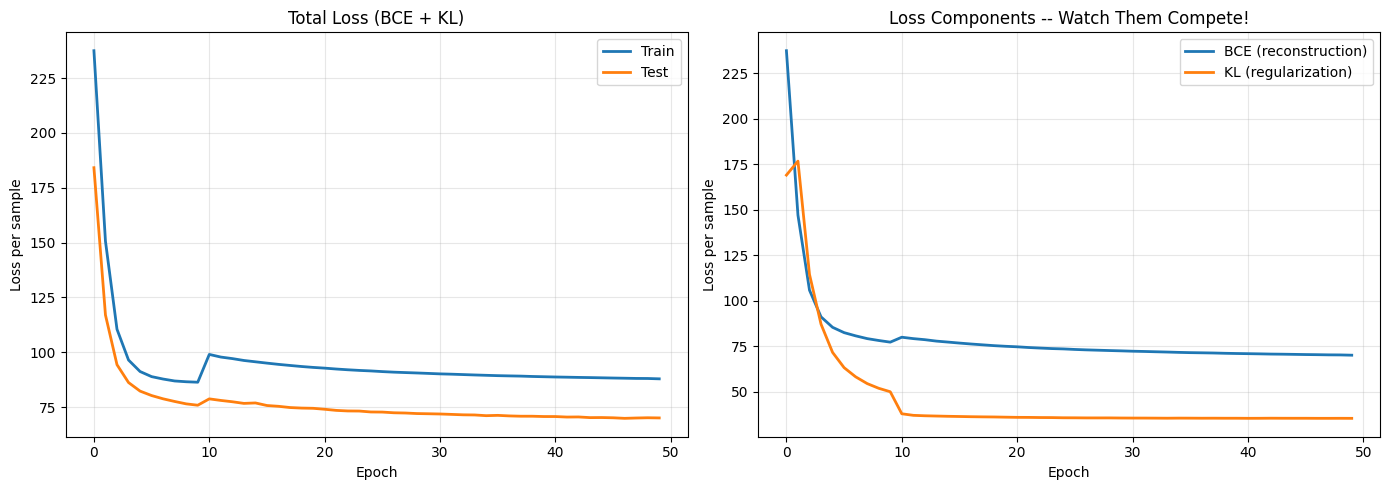

In [10]:
def plot_losses(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    # Total loss
    axes[0].plot(history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(history["test_loss"],  label="Test",  linewidth=2)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss per sample")
    axes[0].set_title("Total Loss (BCE + KL)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # BCE vs KL
    axes[1].plot(history["train_bce"], label="BCE (reconstruction)", linewidth=2)
    axes[1].plot(history["train_kld"], label="KL (regularization)", linewidth=2)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss per sample")
    axes[1].set_title("Loss Components -- Watch Them Compete!")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_losses(history)

In [11]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=10):
    model.eval()

    x, _ = next(iter(loader))
    x = x[:n].to(device)

    y, _, _ = model(x)
    # y= nn.functional.interpolate(y, size=(28,28), mode='bilinear')
    
    x = x.cpu()
    y = y.cpu()

    fig, ax = plt.subplots(2, n, figsize=(n*2, 4))

    for i in range(n):
        ax[0, i].imshow(x[i, 0], cmap="gray")
        ax[0, i].axis("off")

        ax[1, i].imshow(y[i, 0], cmap="gray")
        ax[1, i].axis("off")

    ax[0, 0].set_ylabel("Original", fontsize=12)
    ax[1, 0].set_ylabel("Reconstructed", fontsize=12)

    plt.suptitle("Original (top) vs Reconstructed (bottom)", fontsize=14)
    plt.tight_layout()
    plt.show()

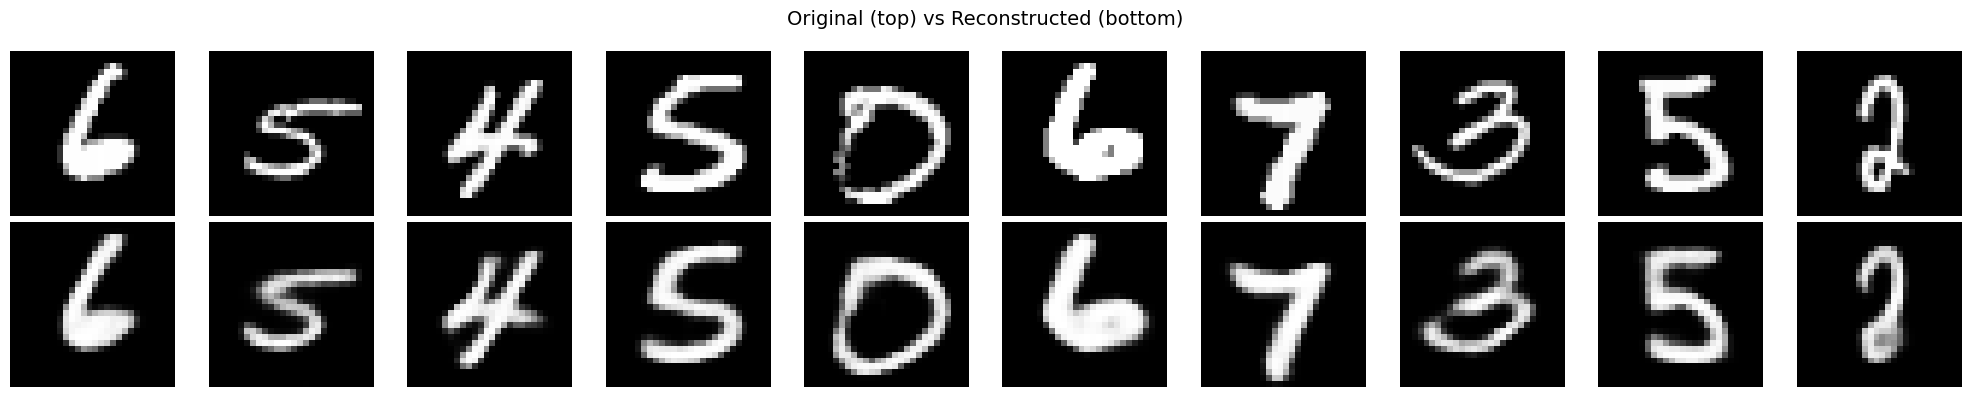

In [12]:
show_reconstructions(model, test_dataloader, device)

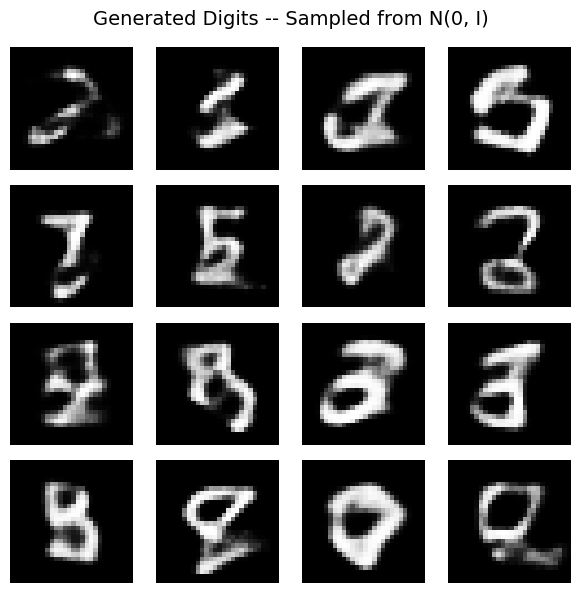

In [20]:
@torch.no_grad()
def generate_samples(model, device, n=16):
    model.eval()

    z = torch.randn(n, 20, device=device) #second parameter is latent dimensions

    samples = model.decode(z)
    # samples= nn.functional.interpolate(samples, size=(28,28), mode='bilinear')
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0].cpu(), cmap='gray')
        ax.axis('off')
    plt.suptitle("Generated Digits -- Sampled from N(0, I)", fontsize=14)
    plt.tight_layout()
    plt.show()

generate_samples(model, device, n=16)

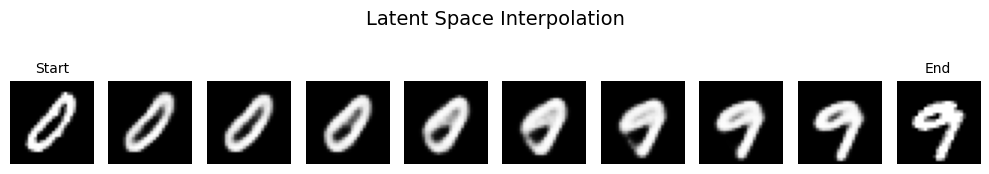

In [14]:
@torch.no_grad()
def interpolate(model, loader, latent_dim=16, steps=8):
    model.eval()
    x, _ = next(iter(loader))

    # Take two real images
    img1 = x[0:1].to(device)
    img2 = x[1:2].to(device)

    # Get their latent codes
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

    # Interpolate
    alphas = torch.linspace(0, 1, steps).to(device)
    interpolations = []
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        recon = model.decode(z_interp)
        # recon = nn.functional.interpolate(recon, size=(28, 28), mode='bilinear')
        interpolations.append(recon)

    # Plot
    fig, axes = plt.subplots(1, steps + 2, figsize=(steps + 2, 2))
    axes[0].imshow(img1[0, 0].cpu(), cmap='gray')
    axes[0].set_title("Start", fontsize=10)
    axes[0].axis('off')

    for i, recon in enumerate(interpolations):
        axes[i+1].imshow(recon[0, 0].cpu(), cmap='gray')
        axes[i+1].axis('off')

    axes[-1].imshow(img2[0, 0].cpu(), cmap='gray')
    axes[-1].set_title("End", fontsize=10)
    axes[-1].axis('off')

    plt.suptitle("Latent Space Interpolation", fontsize=14)
    plt.tight_layout()
    plt.show()

interpolate(model, test_dataloader, steps=8)

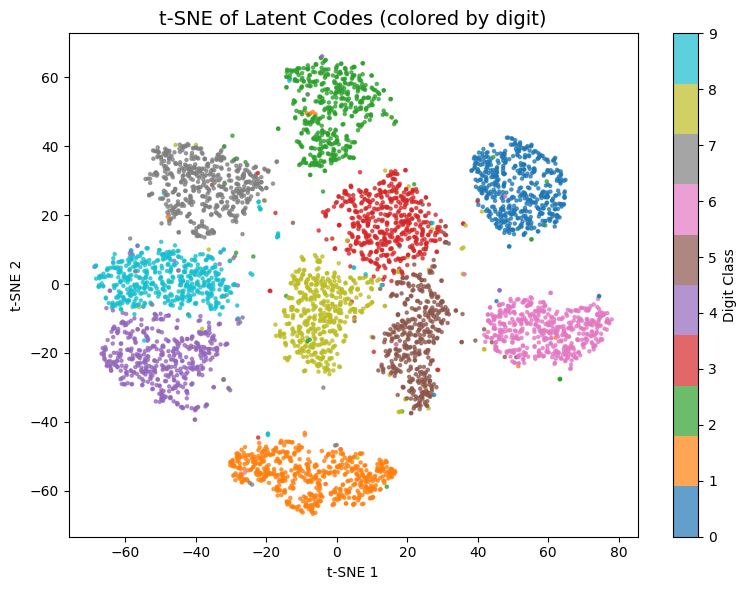

In [15]:
from sklearn.manifold import TSNE

@torch.no_grad()
def plot_latent_tsne(model, loader, n_samples=5000):
    model.eval()
    all_z = []
    all_labels = []

    for x, y in loader:
        x = x.to(device)
        mu, _ = model.encode(x)
        all_z.append(mu.cpu())
        all_labels.append(y)
        if len(torch.cat(all_z)) >= n_samples:
            break

    z = torch.cat(all_z)[:n_samples].numpy()
    labels = torch.cat(all_labels)[:n_samples].numpy()

    # t-SNE to 2D
    z_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(z)

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10',
                         s=5, alpha=0.7)
    plt.colorbar(scatter, label="Digit Class")
    ax.set_title("t-SNE of Latent Codes (colored by digit)", fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

plot_latent_tsne(model, test_dataloader)